<table style="border: none" align="center">
   <tr style="border: none">
      <th style="border: none"><font face="verdana" size="4" color="black"><b>  Demonstrate adversarial samples using ART  </b></font></font></th>
   </tr> 
</table>

In this notebook we demonstrate adversarial samples using ART. Our classifier will be a **ResNet** architecture for the [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) image data set.


## Contents

1.	[Loading prereqs and data](#prereqs)
2.  [Evaluating the classifier](#classifier)

>> Goal:
<font color='red'>This notebook concretely demonstrates the vulnerability of a vision model to adversarial examples, using:</font>

-  CIFAR-10 as the dataset
-  A pre-trained ResNet model
-  ART (Adversarial Robustness Toolbox) to generate the attack
-  An FGSM attack (Fast Gradient Sign Method)

-->Final goal:
To show that perturbations imperceptible to humans can drastically reduce the model’s performance.

In [ ]:
# ============================================================
# Author: Alphabot42, Swiss Cyber Institute
# Tested with Python 3.11.14
# If you are using a different Python version, some packages
# (especially TensorFlow) may require different versions.
# ============================================================


#########################################################################################
# Dependency installation to ensures:                                                   #
#       - a reproducible environment                                                    #
#       - avoidance of package conflicts                                                #
#       - compatibility with TensorFlow and ART                                          #
#########################################################################################
import sys
import platform
import subprocess

def run(cmd):
    subprocess.check_call(cmd)

def pip_install(package):
    try:
        run([sys.executable, "-m", "pip", "install", package])
        print(f"Successfully installed {package}")
    except subprocess.CalledProcessError:
        print(f"Failed to install {package}, trying without version specification")
        # If specific version fails, try installing without version constraint
        if "==" in package:
            base_package = package.split("==")[0]
            try:
                run([sys.executable, "-m", "pip", "install", base_package])
                print(f"Successfully installed {base_package} (latest version)")
            except subprocess.CalledProcessError:
                print(f"Failed to install {base_package}")

def pip_uninstall(package):
    # -y to avoid prompt; ignore errors if not installed
    try:
        run([sys.executable, "-m", "pip", "uninstall", "-y", package])
    except subprocess.CalledProcessError:
        pass

# --- Avoid the common conflict: a different PyPI package named "art"
# ART (Adversarial Robustness Toolbox) is installed via:
#   adversarial-robustness-toolbox
pip_uninstall("art")

# Core packages
packages = [
    "numpy==1.26.4",  # This might be causing the issue - will fall back to latest compatible version
    "scipy",
    "pandas",
    "scikit-learn",
    "matplotlib",
    "pillow",
    "tqdm",
    "scikit-image",
    "tensorflow==2.16.2",
    "opencv-python==4.11.0.86",
    "transformers",
    # Adversarial Robustness Toolbox (this provides: `from art import ...`)
    "adversarial-robustness-toolbox"
]

for pkg in packages:
    pip_install(pkg)

# Install tensorflow-metal ONLY on Apple Silicon (M1/M2/M3)
if platform.system() == "Darwin" and platform.machine() == "arm64":
    pip_install("tensorflow-metal")
    print("Installed tensorflow-metal for Apple Silicon 🚀")
else:
    print("Skipping tensorflow-metal (not Apple Silicon)")

print("\nDone. If imports still fail, restart the Jupyter kernel and re-run your notebook.")



Failed to install numpy==1.26.4, trying without version specification
Failed to install tensorflow==2.16.2, trying without version specification
Skipping tensorflow-metal (not Apple Silicon)

Done. If imports still fail, restart the Jupyter kernel and re-run your notebook.


<a id="prereqs"></a>
## 1. Loading prereqs and data

In [ ]:
import warnings
warnings.filterwarnings('ignore')
#Purely cosmetic for notebook readability.

import tensorflow as tf
from tensorflow.keras.models import load_model

#if tf.__version__[0] == "2":
#    tf.compat.v1.disable_eager_execution()

tf.compat.v1.enable_eager_execution()
# -->immediate computation, which simplifies debugging, ,compatible with ART,is more intuitive for gradient-based attacks

from art import config
from art.utils import load_dataset, get_file
from art.estimators.classification import KerasClassifier  # -->Wrapper between TensorFlow and ART. Allows ART to compute gradients, apply attacks,normalize inputs
from art.attacks.evasion import FastGradientMethod  #-->Implements the FGSM attack, White-box attack, Uses the gradient of the loss
from art.defences.detector.evasion import BinaryInputDetector

import numpy as np
import matplotlib.pyplot as plt

Load the CIFAR10 data set and class descriptions:

In [4]:
(x_train, y_train), (x_test, y_test), min_, max_ = load_dataset('cifar10') #CIFAR-10: more complex than MNIST

num_samples_train = 100 # Subsampling to speeds up notebook execution. sufficient to demonstrate the attack (performance is not the objective)
num_samples_test = 100
x_train = x_train[0:num_samples_train]
y_train = y_train[0:num_samples_train]
x_test = x_test[0:num_samples_test]
y_test = y_test[0:num_samples_test]

class_descr = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

<a id="classifier"></a>
## 2. Evaluating the classifier

Load the pre-trained classifier (a ResNet architecture):

In [5]:
path = get_file('cifar_resnet.h5',extract=False, path=config.ART_DATA_PATH,
                url='https://www.dropbox.com/s/ta75pl4krya5djj/cifar_resnet.h5?dl=1')
classifier_model = load_model(path, compile=False)#-->Model already trained on CIFAR-10, No retraining is performed
#We attack an existing model, as in real-world scenarios
#compilation. require to evaluate the model and compute the loss used by the FGSM attack
classifier_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"],
)
#! Without this step, attacks cannot be performed:ART needs to know how to normalize inputs, know pixel value bounds, access model gradients
classifier = KerasClassifier(clip_values=(min_, max_), model=classifier_model, use_logits=False, 
                             preprocessing=(0.5, 1))

In [6]:
classifier_model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_1 (InputLayer)          │ (None, 32, 32, 3)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 32, 32, 16)        │             448 │ input_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 32, 32, 16)        │              64 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 32, 32, 16)        │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 32, 32, 16)        │           2,320 │ activation_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 32, 32, 16)        │              64 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_2 (Activation)     │ (None, 32, 32, 16)        │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 32, 32, 16)        │           2,320 │ activation_2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_1 (Add)                   │ (None, 32, 32, 16)        │               0 │ activation_1[0][0],        │
│                               │                           │                 │ conv2d_3[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 32, 32, 16)        │              64 │ add_1[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_3 (Activation)     │ (None, 32, 32, 16)        │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 32, 32, 16)        │           2,320 │ activation_3[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_4         │ (None, 32, 32, 16)        │              64 │ conv2d_4[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_4 (Activation)     │ (None, 32, 32, 16)        │               0 │ batch_normalization_4[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 32, 32, 16)        │           2,32

 Total params: 470,218 (1.79 MB)

 Trainable params: 467,946 (1.79 MB)

 Non-trainable params: 2,272 (8.88 KB)

Evaluate the classifier on the first 100 test images:

<font color='green'>Expected result:</font>
-  good accuracy, 
-  functional model, 
-  baseline before the attack

 <font color='green'>Visualization:</font>
-  image,
-  model prediction,
-  true class (real label assigned to the image in the dataset. A cat is a cat)

In [7]:
x_test_pred = np.argmax(classifier.predict(x_test[:100]), axis=1)
nb_correct_pred = np.sum(x_test_pred == np.argmax(y_test[:100], axis=1))

print("Original test data (first 100 images):")
print("Correctly classified: {}".format(nb_correct_pred))
print("Incorrectly classified: {}".format(100-nb_correct_pred))

Original test data (first 100 images):
Correctly classified: 98
Incorrectly classified: 2


For illustration purposes, look at the first 9 images. (In brackets: true labels.)

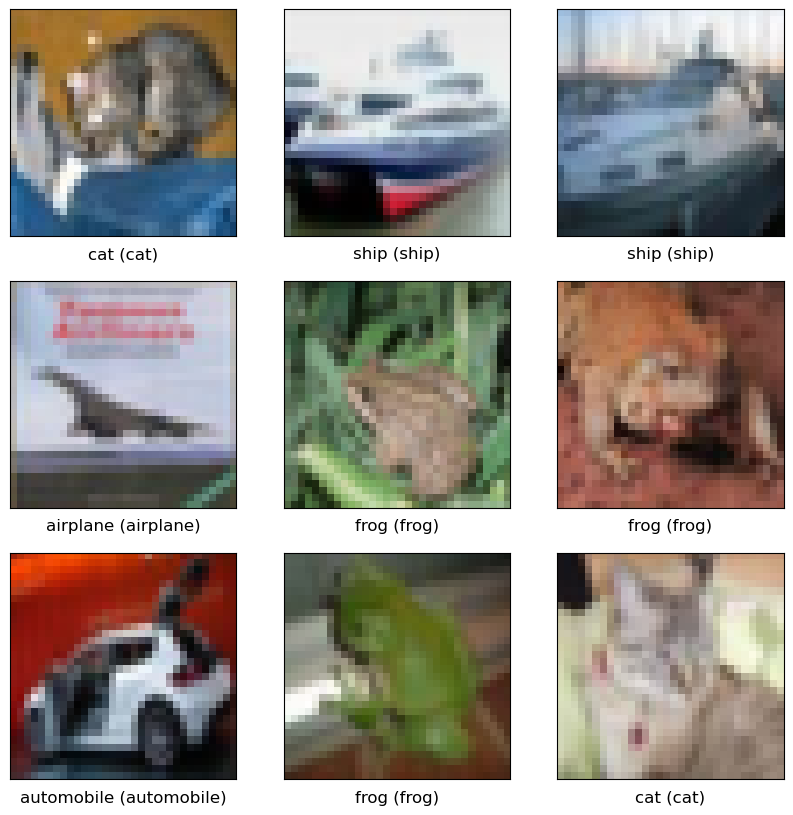

In [8]:
plt.figure(figsize=(10,10))
for i in range(0, 9):
    pred_label, true_label = class_descr[x_test_pred[i]], class_descr[np.argmax(y_test[i])]
    plt.subplot(330 + 1 + i)
    fig=plt.imshow(x_test[i])
    fig.axes.get_xaxis().set_visible(False)
    fig.axes.get_yaxis().set_visible(False)
    fig.axes.text(0.5, -0.1, pred_label + " (" + true_label + ")", fontsize=12, transform=fig.axes.transAxes, 
                  horizontalalignment='center')

<font color='red'>Generate some adversarial samples:</font>

In [9]:
attacker = FastGradientMethod(classifier, eps=0.05)
#eps=maximum perturbation amplitude.0.05 is almost invisible to the human eye.sufficient to fool the network
x_test_adv = attacker.generate(x_test[:100]) # this takes about two minutes

>> <font color='red'>The attack:</font>



*  computes the gradient of the loss

*  pushes the image in the direction that maximizes error

*  keeps values within pixel bounds

Evaluate the classifier on 100 adversarial samples:

In [10]:
x_test_adv_pred = np.argmax(classifier.predict(x_test_adv), axis=1)
nb_correct_adv_pred = np.sum(x_test_adv_pred == np.argmax(y_test[:100], axis=1))

print("Adversarial test data (first 100 images):")
print("Correctly classified: {}".format(nb_correct_adv_pred))
print("Incorrectly classified: {}".format(100-nb_correct_adv_pred))

Adversarial test data (first 100 images):
Correctly classified: 20
Incorrectly classified: 80


Now plot the adversarial images and their predicted labels (in brackets: true labels).

<font color='red'>Display the adversarial images together with:</font>

*  the model prediction

*  the true class (true label) shown in parentheses


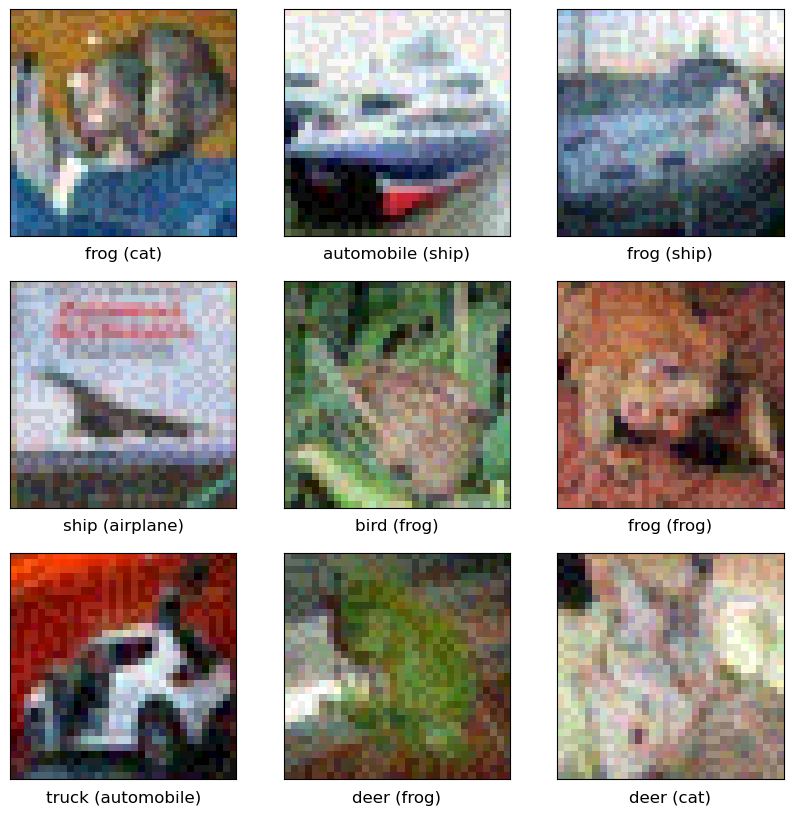

In [ ]:
plt.figure(figsize=(10,10))#Creates a 10×10 figure to display multiple images.
#plt.figure(figsize=(6,6))
for i in range(0, 9):
    pred_label, true_label = class_descr[x_test_adv_pred[i]], class_descr[np.argmax(y_test[i])]
    #predicted label by the model after the attack. true label of the image from the dataset
    plt.subplot(330 + 1 + i)#Splits the figure into a 3 × 3 grid to display the 9 images
    fig=plt.imshow(x_test_adv[i])#Displays the attacked (adversarial) image.
    #fig=plt.imshow(x_test[i], interpolation="nearest")
    fig.axes.get_xaxis().set_visible(False)#Hides the axes to make the image easier to read.
    fig.axes.get_yaxis().set_visible(False)
    fig.axes.text(0.5, -0.1, pred_label + " (" + true_label + ")", fontsize=12, transform=fig.axes.transAxes, 
                  horizontalalignment='center')

<font color='red'>-->This allows us to visually observe that the image looks normal to a human, but the model prediction is incorrect.</font>
*  the image appears normal to humans but the prediction changes

 <font color='red'>--> so the model is vulnerable to adversarial examples</font>